In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
import zipfile


In [ ]:
import os
import zipfile
import gdown

# 1. Extraer el ID del archivo desde el enlace compartido
file_id = '1iR-_h-xHfI5F_m3J98sSu0jXPJtbExVx'
url = f'https://drive.google.com/uc?id={file_id}'

# 2. Ruta local donde se guardará el archivo .zip descargado
archivo_zip_local = 'dataset_descargado.zip'

print("Descargando el dataset desde Google Drive...")
gdown.download(url, archivo_zip_local, quiet=False)

# 3. Ruta donde se descomprimirá el dataset
extract_path = 'dataset_tomato'
os.makedirs(extract_path, exist_ok=True)

print("Descomprimiendo el dataset...")
with zipfile.ZipFile(archivo_zip_local, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
    print("¡Listo! Dataset descomprimido.")

Descargando el dataset desde Google Drive...


Downloading...
From (original): https://drive.google.com/uc?id=1iR-_h-xHfI5F_m3J98sSu0jXPJtbExVx
From (redirected): https://drive.google.com/uc?id=1iR-_h-xHfI5F_m3J98sSu0jXPJtbExVx&confirm=t&uuid=09b2cc66-bc78-4141-88fe-69d3eb4b96da
To: /content/dataset_descargado.zip
100%|██████████| 109M/109M [00:00<00:00, 149MB/s] 


Descomprimiendo el dataset...
¡Listo! Dataset descomprimido.


In [ ]:
base_dir = 'dataset_tomato'

print(f"--- Explorando el contenido de '{base_dir}' ---")
if not os.path.exists(base_dir):
    print(f"La ruta {base_dir} no existe. Revisa dónde se descomprimió.")
else:
    # Listar el primer nivel dentro de base_dir
    primer_nivel = os.listdir(base_dir)
    print(f"Elementos en el primer nivel: {primer_nivel}")

    # Si detectamos una sola carpeta contenedora, bajamos un nivel para mostrar su contenido
    if len(primer_nivel) == 1 and os.path.isdir(os.path.join(base_dir, primer_nivel[0])):
        sub_carpeta = os.path.join(base_dir, primer_nivel[0])
        print(f"\n¡Ojo! Parece que hay una carpeta contenedora: '{primer_nivel[0]}'")
        print(f"Elementos dentro de '{primer_nivel[0]}': {os.listdir(sub_carpeta)}")

--- Explorando el contenido de 'dataset_tomato' ---
Elementos en el primer nivel: ['Dataset']

¡Ojo! Parece que hay una carpeta contenedora: 'Dataset'
Elementos dentro de 'Dataset': ['train', 'test', 'val']


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ajustamos la ruta base incluyendo la carpeta 'Dataset' que descubrimos
base_dir = 'dataset_tomato/Dataset'

# Actualizamos 'val' según el nombre real de tu carpeta
splits = ['train', 'val', 'test']
data_summary = []

for split in splits:
    split_path = os.path.join(base_dir, split)
    if not os.path.exists(split_path):
        print(f"Advertencia: No se encontró la ruta {split_path}")
        continue

    classes = sorted(os.listdir(split_path))
    for cls in classes:
        cls_path = os.path.join(split_path, cls)
        if os.path.isdir(cls_path):
            # Contar archivos de imagen
            num_images = len([f for f in os.listdir(cls_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
            data_summary.append({
                'Split': split,
                'Clase': cls,
                'Cantidad': num_images
            })

# Convertir a DataFrame para visualizar
df_summary = pd.DataFrame(data_summary)

print("--- Resumen de la Partición y Balance por Clase ---")
print(df_summary.to_string(index=False))



--- Resumen de la Partición y Balance por Clase ---
Split                       Clase  Cantidad
train     Tomato___Bacterial_spot       768
train       Tomato___Early_blight       762
train        Tomato___Late_blight       763
train          Tomato___Leaf_Mold       760
train Tomato___Septoria_leaf_spot       768
train            Tomato___healthy       765
  val     Tomato___Bacterial_spot       164
  val       Tomato___Early_blight       163
  val        Tomato___Late_blight       163
  val          Tomato___Leaf_Mold       163
  val Tomato___Septoria_leaf_spot       164
  val            Tomato___healthy       164
 test     Tomato___Bacterial_spot       166
 test       Tomato___Early_blight       164
 test        Tomato___Late_blight       165
 test          Tomato___Leaf_Mold       164
 test Tomato___Septoria_leaf_spot       166
 test            Tomato___healthy       165


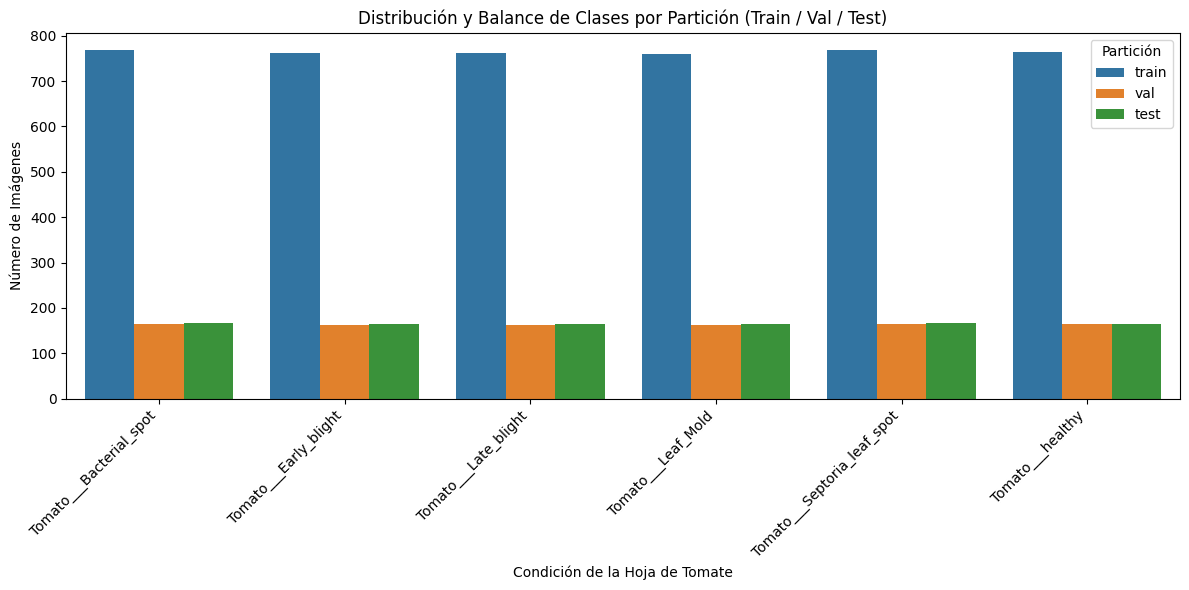

In [ ]:
# Gráfico de barras para ver el balance visualmente
plt.figure(figsize=(12, 6))
sns.barplot(data=df_summary, x='Clase', y='Cantidad', hue='Split')
plt.title('Distribución y Balance de Clases por Partición (Train / Val / Test)')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Condición de la Hoja de Tomate')
plt.ylabel('Número de Imágenes')
plt.legend(title='Partición')
plt.tight_layout()
plt.show()

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# 1. Definir la ruta base del dataset (ajustada a tu estructura con 'Dataset')
base_dir = 'dataset_tomato/Dataset'



In [ ]:
# 2. Función para extraer características de color usando el espacio HSV
def extract_hsv_features(image_path, bins=(8, 8, 8)):
    img = cv2.imread(image_path)
    if img is None:
        return None
    # Convertir de BGR a HSV (Hue, Saturation, Value)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    # Calcular histograma tridimensional para H, S y V
    hist = cv2.calcHist([hsv], [0, 1, 2], None, bins, [0, 180, 0, 256, 0, 256])
    # Normalizar el histograma para que no dependa del tamaño de la imagen
    cv2.normalize(hist, hist)
    return hist.flatten()

# 3. Función para procesar y cargar todas las imágenes de una partición
def load_dataset_features(base_dir, split):
    split_path = os.path.join(base_dir, split)
    features = []
    labels = []
    classes = sorted(os.listdir(split_path))

    print(f"Extrayendo características HSV para la partición: {split}...")
    for cls in classes:
        cls_path = os.path.join(split_path, cls)
        if not os.path.isdir(cls_path):
            continue
        for img_name in os.listdir(cls_path):
            if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                img_path = os.path.join(cls_path, img_name)
                feat = extract_hsv_features(img_path)
                if feat is not None:
                    features.append(feat)
                    labels.append(cls)

    return np.array(features), np.array(labels), classes



In [ ]:
# Cargar los conjuntos de entrenamiento y prueba
X_train, y_train, classes = load_dataset_features(base_dir, 'train')
X_test, y_test, _ = load_dataset_features(base_dir, 'val')

print(f"\n¡Extracción completada!")
print(f"Dimensiones X_train: {X_train.shape}")
print(f"Dimensiones X_test: {X_test.shape}")

# 4. Entrenar la Línea Base Estricta (Regresión Logística)
print("\nEntrenando modelo de Regresión Logística (Línea Base)...")
clf = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)

# 5. Evaluar el modelo en el conjunto de prueba (Test)
y_pred = clf.predict(X_test)

print("\n--- Reporte de Clasificación (Baseline HSV) ---")
print(classification_report(y_test, y_pred))



Extrayendo características HSV para la partición: train...
Extrayendo características HSV para la partición: val...

¡Extracción completada!
Dimensiones X_train: (4586, 512)
Dimensiones X_test: (981, 512)

Entrenando modelo de Regresión Logística (Línea Base)...

--- Reporte de Clasificación (Baseline HSV) ---
                             precision    recall  f1-score   support

    Tomato___Bacterial_spot       0.95      0.96      0.95       164
      Tomato___Early_blight       0.86      0.86      0.86       163
       Tomato___Late_blight       0.88      0.75      0.81       163
         Tomato___Leaf_Mold       0.90      0.96      0.93       163
Tomato___Septoria_leaf_spot       0.89      0.93      0.91       164
           Tomato___healthy       0.95      0.98      0.96       164

                   accuracy                           0.91       981
                  macro avg       0.91      0.91      0.90       981
               weighted avg       0.91      0.91      0.90       

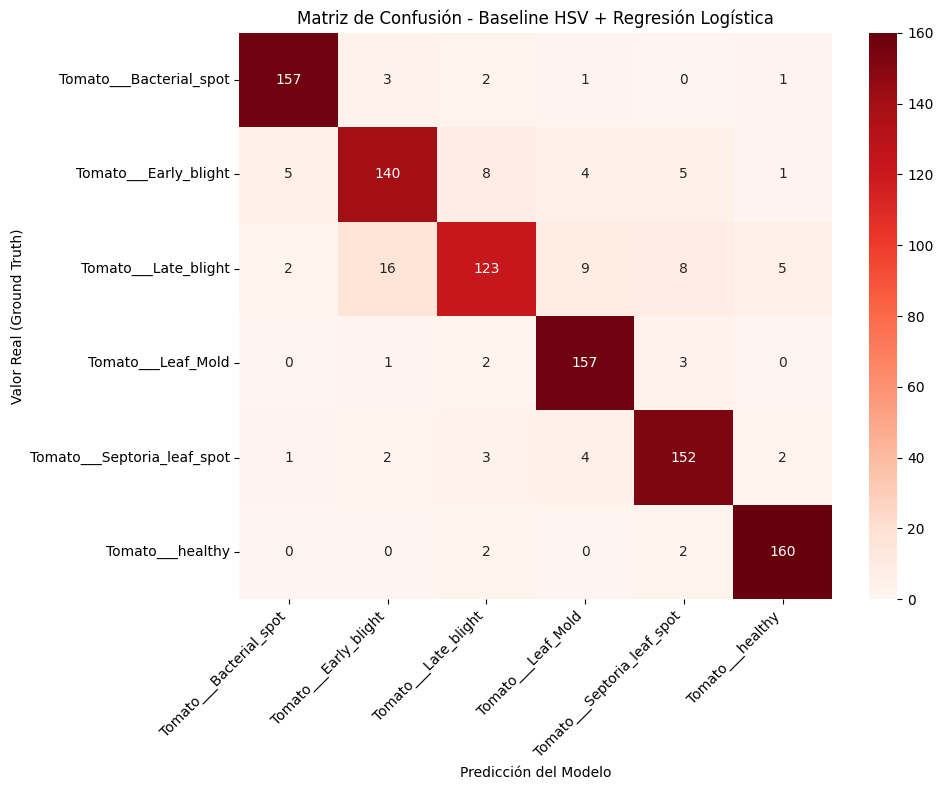

In [ ]:
# 6. Generar la Matriz de Confusión para analizar las fallas entre clases similares
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred, labels=classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=classes, yticklabels=classes)
plt.title('Matriz de Confusión - Baseline HSV + Regresión Logística')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real (Ground Truth)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

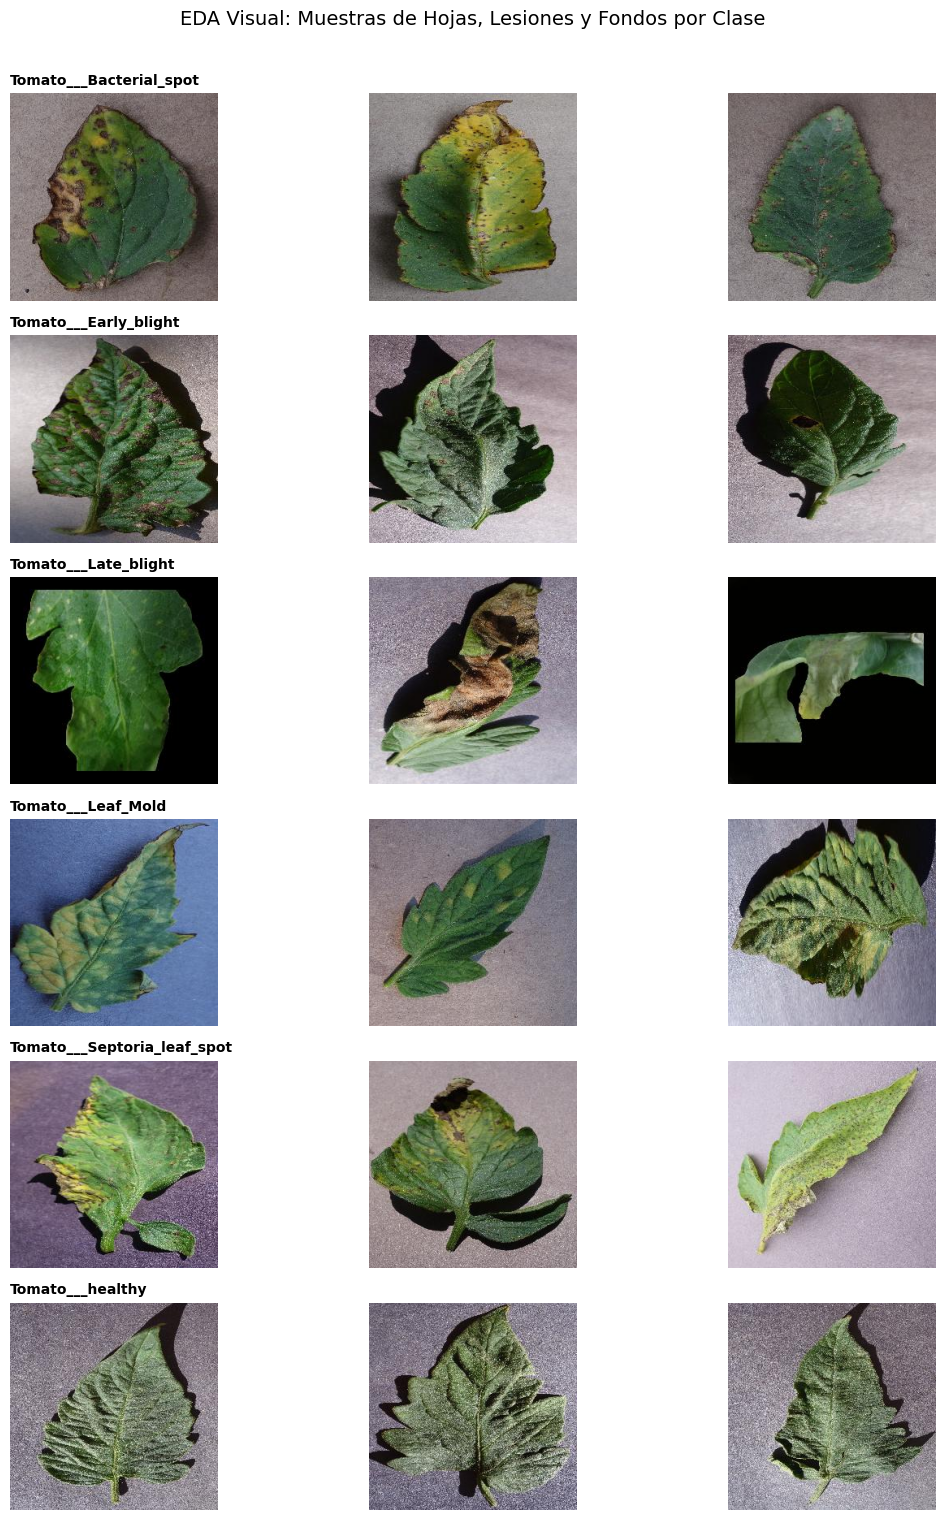

In [ ]:
import os
import random
import cv2
import matplotlib.pyplot as plt

base_dir = 'dataset_tomato/Dataset'

def eda_galeria_clases(base_dir, split='train', samples_per_class=3):
    split_path = os.path.join(base_dir, split)
    classes = sorted([d for d in os.listdir(split_path) if os.path.isdir(os.path.join(split_path, d))])

    fig, axes = plt.subplots(len(classes), samples_per_class, figsize=(12, 2.5 * len(classes)))

    for row, cls in enumerate(classes):
        cls_path = os.path.join(split_path, cls)
        images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        selected_imgs = random.sample(images, min(samples_per_class, len(images)))

        for col, img_name in enumerate(selected_imgs):
            img_path = os.path.join(cls_path, img_name)
            img = cv2.imread(img_path)
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            ax = axes[row, col] if len(classes) > 1 else axes[col]
            ax.imshow(img_rgb)
            ax.axis('off')

            if col == 0:
                ax.set_title(f"{cls}", fontsize=10, fontweight='bold', loc='left')

    plt.suptitle("EDA Visual: Muestras de Hojas, Lesiones y Fondos por Clase", y=1.01, fontsize=14)
    plt.tight_layout()
    plt.show()

# Ejecutar Galería
eda_galeria_clases(base_dir, split='train', samples_per_class=3)

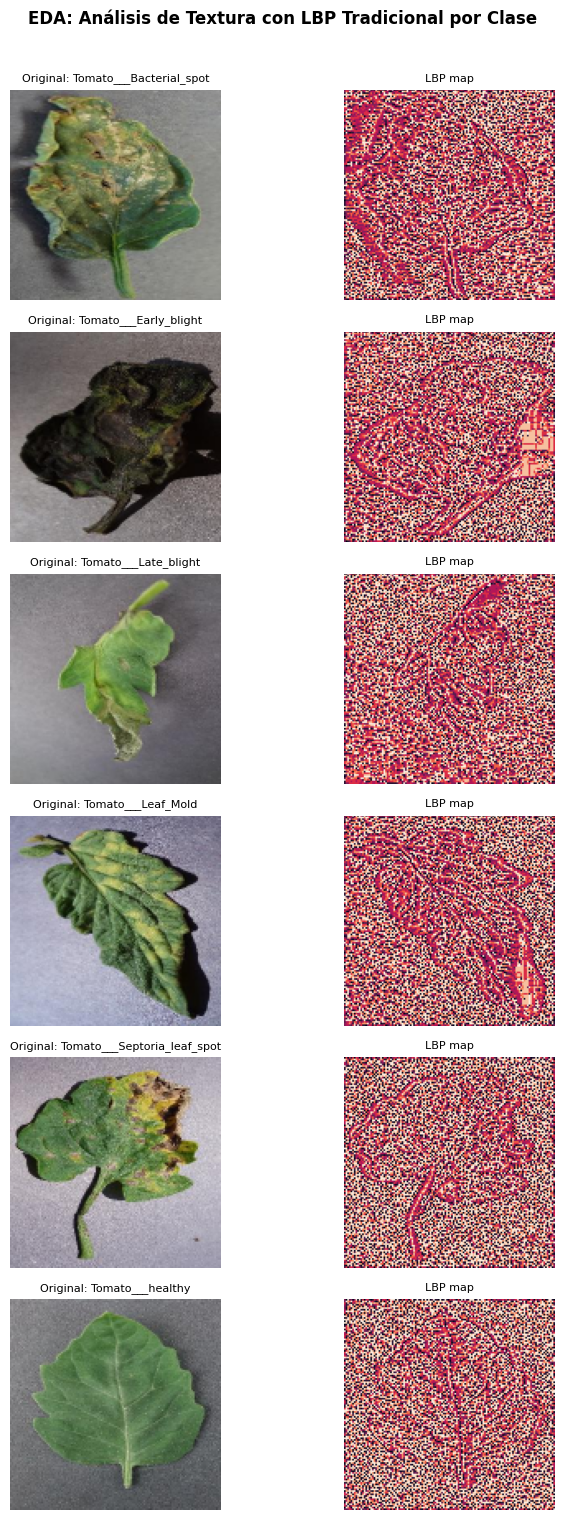

In [ ]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import local_binary_pattern

base_dir = 'dataset_tomato/Dataset'

def eda_lbp_clasico(base_dir, split='train'):
    split_path = os.path.join(base_dir, split)
    classes = sorted([d for d in os.listdir(split_path) if os.path.isdir(os.path.join(split_path, d))])

    muestras = []
    for cls in classes:
        cls_path = os.path.join(split_path, cls)
        images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if images:
            img_name = random.choice(images)
            muestras.append((os.path.join(cls_path, img_name), cls))

    # Creamos una figura de dos columnas por cada clase: (Original | LBP Clásico)
    fig, axes = plt.subplots(len(muestras), 2, figsize=(8, 2.5 * len(muestras)))

    for i, (img_path, cls) in enumerate(muestras):
        img = cv2.imread(img_path)

        # 1. Redimensionar para estandarizar el tamaño del grano de la textura
        img = cv2.resize(img, (128, 128))

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # 2. Aplicar LBP Clásico Tradicional (Radio=1, Vecinos=8)
        # Usamos 'uniform' que es el estándar más publicado para texturas en ML
        radius = 1
        n_points = 8 * radius
        lbp = local_binary_pattern(gray, P=n_points, R=radius, method='uniform')

        # Columna 1: Imagen Original a color
        axes[i, 0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axes[i, 0].set_title(f"Original: {cls}", fontsize=8)
        axes[i, 0].axis('off')

        # Columna 2: Mapa LBP Clásico
        axes[i, 1].imshow(lbp, cmap='rocket')
        axes[i, 1].set_title("LBP map", fontsize=8)
        axes[i, 1].axis('off')

    plt.suptitle("EDA: Análisis de Textura con LBP Tradicional por Clase", y=1.01, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Ejecutar la versión con LBP clásico
eda_lbp_clasico(base_dir, split='train')

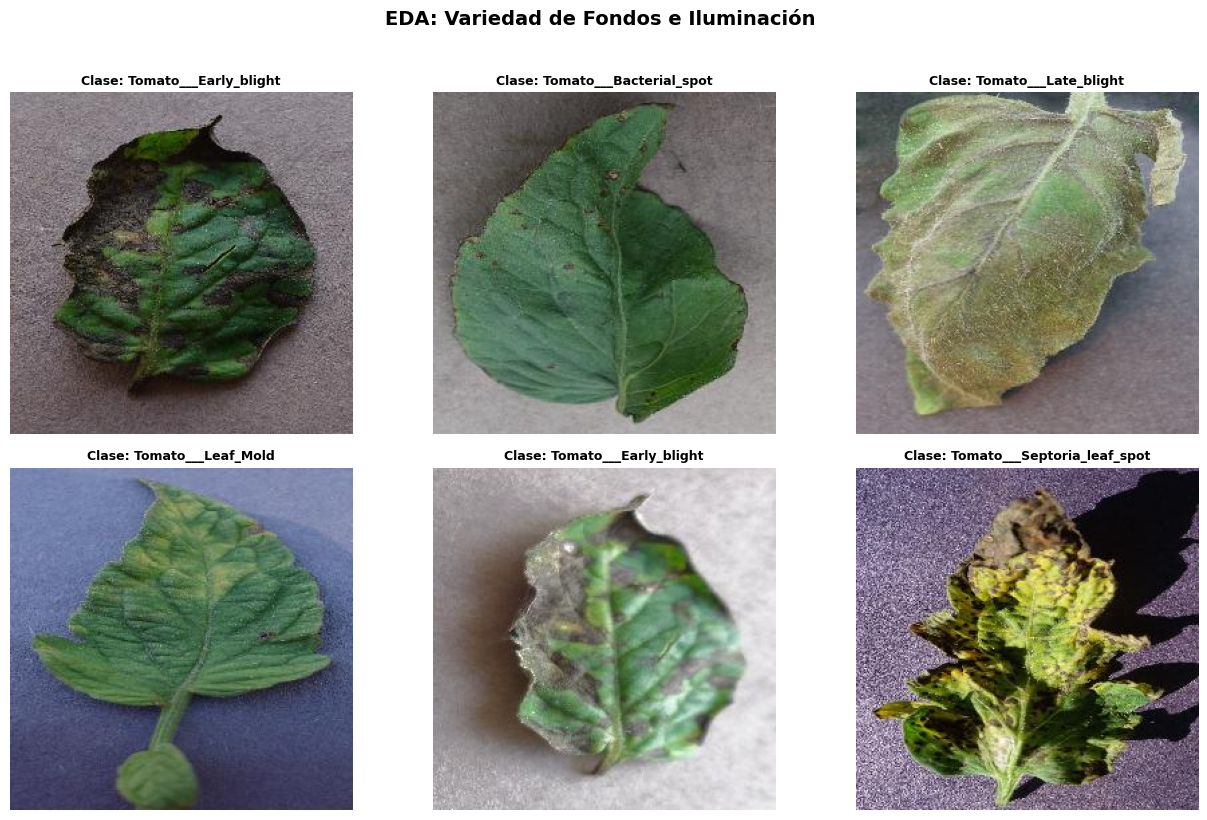

In [ ]:
import os
import cv2
import random
import matplotlib.pyplot as plt

base_dir = 'dataset_tomato/Dataset'

def eda_mostrar_fondos_originales(base_dir, split='train', num_samples=6):
    split_path = os.path.join(base_dir, split)

    # Recopilar todas las rutas de imágenes y sus clases
    todas_las_imagenes = []
    classes = sorted([d for d in os.listdir(split_path) if os.path.isdir(os.path.join(split_path, d))])

    for cls in classes:
        cls_path = os.path.join(split_path, cls)
        for f in os.listdir(cls_path):
            if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                todas_las_imagenes.append((os.path.join(cls_path, f), cls))

    # Seleccionar muestras completamente al azar
    muestras = random.sample(todas_las_imagenes, min(num_samples, len(todas_las_imagenes)))

    # Configurar una cuadrícula organizada (3 columnas)
    cols = 3
    rows = (len(muestras) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(13, 4 * rows))
    axes = axes.flatten()

    for i, (img_path, cls) in enumerate(muestras):
        img = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        axes[i].imshow(img_rgb)
        axes[i].set_title(f"Clase: {cls}", fontsize=9, fontweight='bold')
        axes[i].axis('off')

    # Ocultar espacios vacíos si la cuadrícula sobra
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.suptitle("EDA: Variedad de Fondos e Iluminación ", y=1.02, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Ejecutar la visualización directa de los fondos originales
eda_mostrar_fondos_originales(base_dir, split='train', num_samples=6)

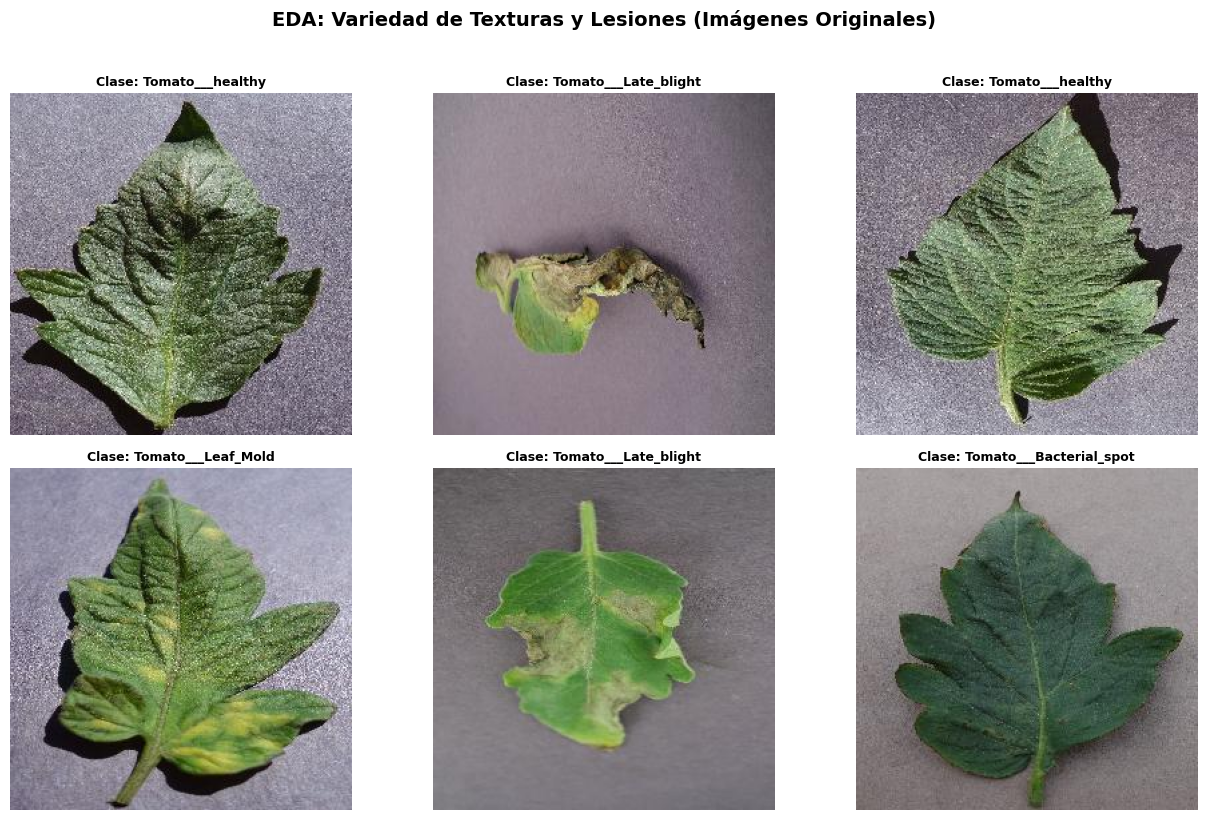

In [ ]:
import os
import cv2
import random
import matplotlib.pyplot as plt

base_dir = 'dataset_tomato/Dataset'

def eda_mostrar_texturas_originales(base_dir, split='train', num_samples=6):
    split_path = os.path.join(base_dir, split)

    # Recopilar todas las rutas de imágenes y sus clases
    todas_las_imagenes = []
    classes = sorted([d for d in os.listdir(split_path) if os.path.isdir(os.path.join(split_path, d))])

    for cls in classes:
        cls_path = os.path.join(split_path, cls)
        for f in os.listdir(cls_path):
            if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                todas_las_imagenes.append((os.path.join(cls_path, f), cls))

    # Seleccionar muestras completamente al azar
    muestras = random.sample(todas_las_imagenes, min(num_samples, len(todas_las_imagenes)))

    # Configurar una cuadrícula organizada (3 columnas)
    cols = 3
    rows = (len(muestras) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(13, 4 * rows))
    axes = axes.flatten()

    for i, (img_path, cls) in enumerate(muestras):
        img = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        axes[i].imshow(img_rgb)
        axes[i].set_title(f"Clase: {cls}", fontsize=9, fontweight='bold')
        axes[i].axis('off')

    # Ocultar espacios vacíos si la cuadrícula sobra
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.suptitle("EDA: Variedad de Texturas y Lesiones (Imágenes Originales)", y=1.02, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Ejecutar la visualización directa de texturas originales
eda_mostrar_texturas_originales(base_dir, split='train', num_samples=6)



aaaa

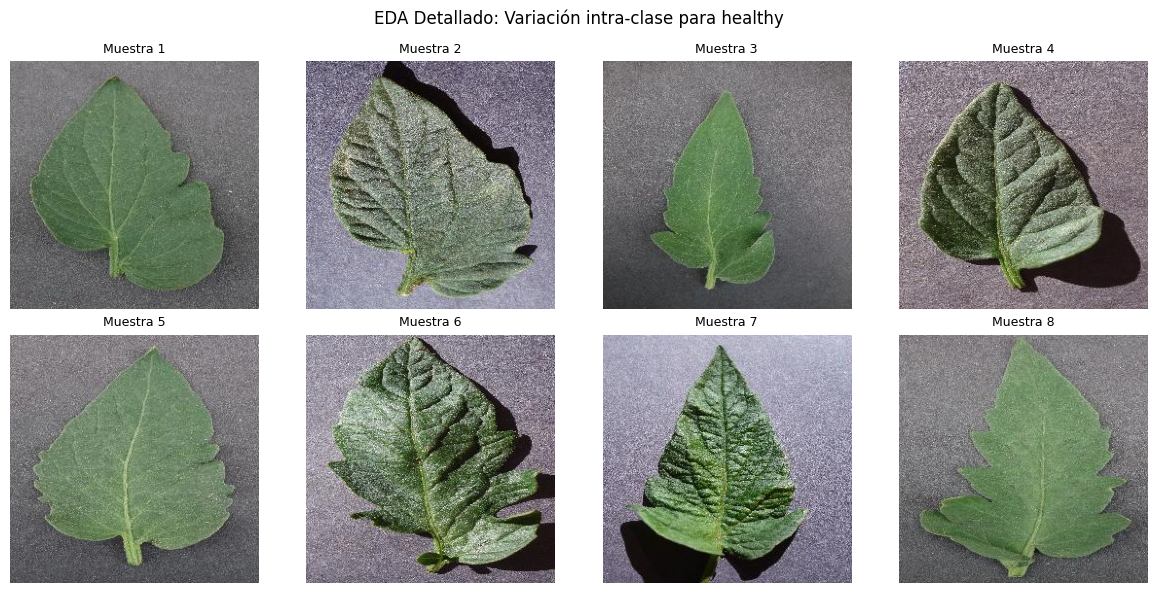

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt

base_dir = 'dataset_tomato/Dataset/train'

# --- CAMBIA AQUí LA CLASE QUE QUIERES INSPECCIONAR ---
# Opciones: 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight',
#           'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___healthy'
clase_objetivo = 'Tomato___healthy'

cls_path = os.path.join(base_dir, clase_objetivo)
imagenes = os.listdir(cls_path)[:8] # Muestra 8 ejemplos de esa clase

plt.figure(figsize=(12, 6))
for i, img_name in enumerate(imagenes):
    img_path = os.path.join(cls_path, img_name)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.title(f"Muestra {i+1}", fontsize=9)
    plt.axis('off')

plt.suptitle(f'EDA Detallado: Variación intra-clase para {clase_objetivo.replace("Tomato___", "")}', fontsize=12)
plt.tight_layout()
plt.show()

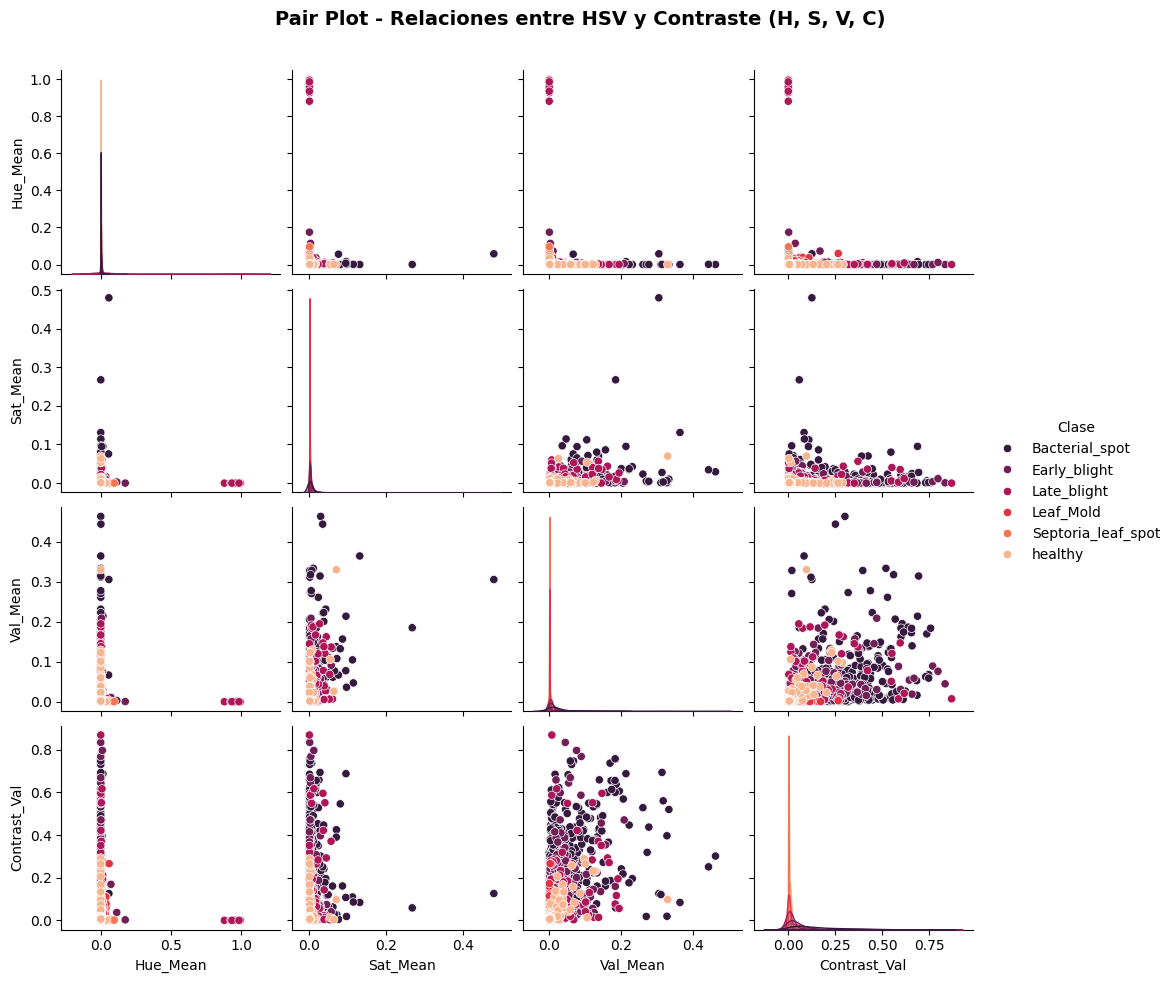

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Convertir la muestra de características estadísticas (H, S, V, C) a DataFrame
df_hsv_c = pd.DataFrame(X_train[:, :4], columns=['Hue_Mean', 'Sat_Mean', 'Val_Mean', 'Contrast_Val'])
df_hsv_c['Clase'] = [c.replace('Tomato___', '') for c in y_train]

# 2. Generar el pair plot correctamente configurado con Seaborn
g = sns.pairplot(df_hsv_c, hue='Clase', palette='rocket', diag_kind='kde', height=2.5)

# Añadir el título general ajustado al objeto PairGrid
g.fig.subplots_adjust(top=0.92)
g.fig.suptitle("Pair Plot - Relaciones entre HSV y Contraste (H, S, V, C)", fontsize=14, fontweight='bold')

plt.show()

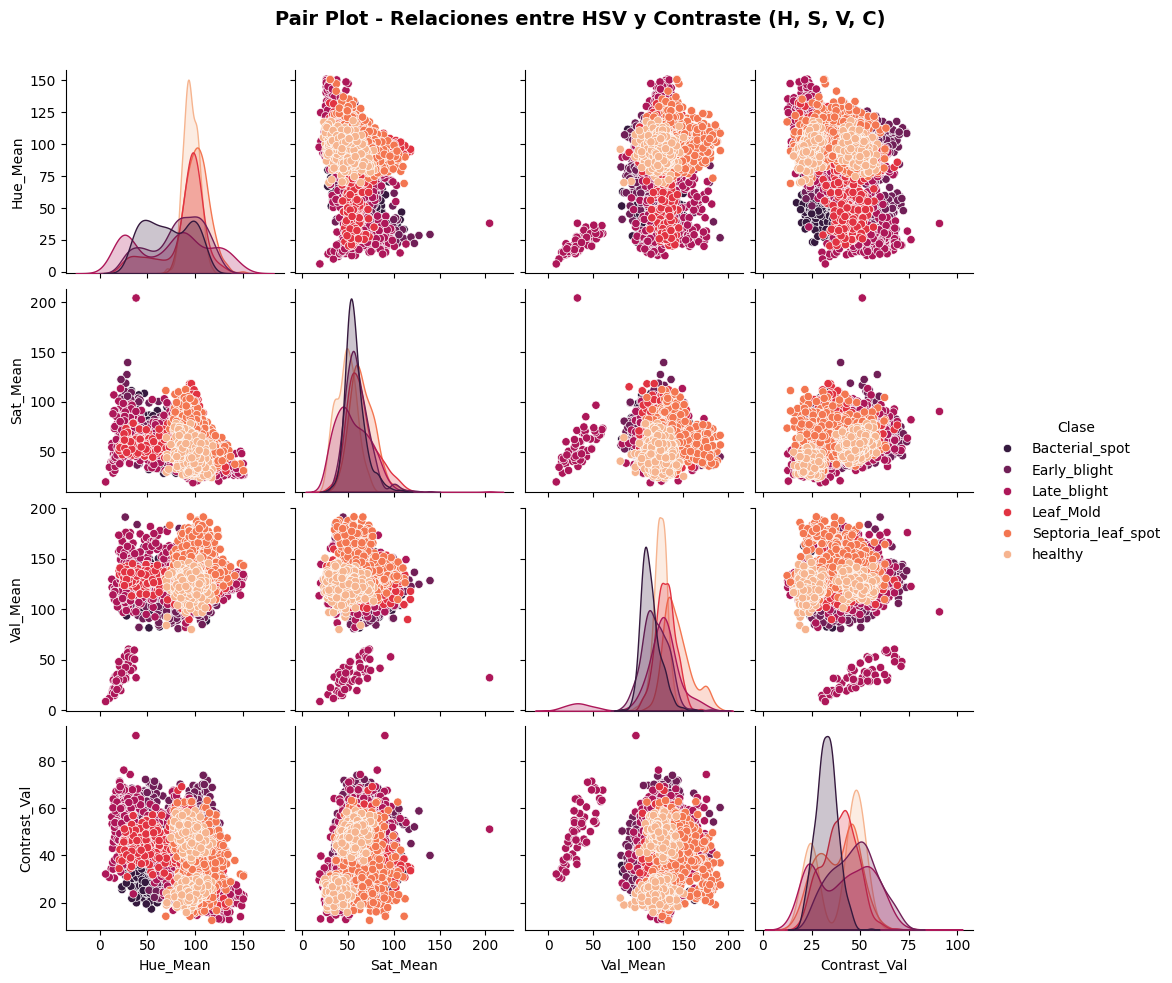

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Extraer las verdaderas 4 características estadísticas (H, S, V, C) de cada imagen de entrenamiento
features_stats = []
labels_list = []

base_dir = 'dataset_tomato/Dataset'
train_path = os.path.join(base_dir, 'train')
classes = sorted(os.listdir(train_path))

for cls in classes:
    cls_path = os.path.join(train_path, cls)
    if not os.path.isdir(cls_path):
        continue
    for img_name in os.listdir(cls_path):
        if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
            img_path = os.path.join(cls_path, img_name)
            img = cv2.imread(img_path)
            if img is not None:
                hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
                h, s, v = cv2.split(hsv)
                # Aquí se calculan de verdad
                hue_mean = np.mean(h)
                sat_mean = np.mean(s)
                val_mean = np.mean(v)
                contrast_val = np.std(v) # C de Contraste (Desviación estándar de V)

                features_stats.append([hue_mean, sat_mean, val_mean, contrast_val])
                labels_list.append(cls)

# 2. Ahora sí, convertir a DataFrame con los nombres correctos
df_hsv_c = pd.DataFrame(features_stats, columns=['Hue_Mean', 'Sat_Mean', 'Val_Mean', 'Contrast_Val'])
df_hsv_c['Clase'] = [c.replace('Tomato___', '') for c in labels_list]

# 3. Generar el pair plot
g = sns.pairplot(df_hsv_c, hue='Clase', palette='rocket', diag_kind='kde', height=2.5)
g.fig.subplots_adjust(top=0.92)
g.fig.suptitle("Pair Plot - Relaciones entre HSV y Contraste (H, S, V, C)", fontsize=14, fontweight='bold')
plt.show()